In [1]:
# # Run this and then restart the kernel at the start of each session to install
# # 'teotil3' in development mode
# !pip install -e /home/jovyan/projects/teotil3/

In [2]:
import contextily as cx
import geopandas as gpd
import matplotlib.pyplot as plt
import networkx as nx
import nivapy3 as nivapy
import pandas as pd
import teotil3 as teo
from matplotlib.lines import Line2D
from matplotlib.patches import Patch
from matplotlib_scalebar.scalebar import ScaleBar
from shapely.geometry import box
from xyzservices import TileProvider

plt.style.use("ggplot")

In [3]:
eng = nivapy.da.connect_postgis()

Connection successful.


In [4]:
# Define providers for Kartverket basemaps
kartverket = TileProvider(
    name="Kartverket",
    url="https://cache.kartverket.no/v1/wmts/1.0.0/topo/default/webmercator/{z}/{y}/{x}.png",
    attribution="© Kartverket",
)

kartverket_gra = TileProvider(
    name="Kartverket",
    url="https://cache.kartverket.no/v1/wmts/1.0.0/topograatone/default/webmercator/{z}/{y}/{x}.png",
    attribution="© Kartverket",
)

# TEOTIL3 for Lillestrøm kommune
# Notebook 08: Catchment maps

This notebook creates standardised maps and plots for each catchment.

## 1. Derive catchment boundaries

In [5]:
# Read catchment data
xl_path = r"../data/lillestrom_monitoring_sites.xlsx"
cat_df = pd.read_excel(xl_path, sheet_name="catch_outlets")
cat_df

,cat_id,regine,name,outlet_lon,outlet_lat,nve_area_km2,comment
0,1,002.CBA0,Sagelva,11.02384,59.95745,109,Tributary to Nitelva
1,2,002.CB0,Nitelva,11.07092,59.93806,484,Just upstream of confluence with Leira
2,3,002.CAA0,Leira,11.07367,59.93905,668,Just upstream of confluence with Nitelva
3,4,002.D2Z,Rømua,11.20984,59.99055,212,Single REGINE; no lakes; inputs only?
4,5,002.CAA0,Jeksla,11.09281,59.99753,17,Small sub-catchment of Leira; not resolved by ...
5,6,002.D3Z,Åa,11.28279,59.99649,131,Single REGINE; few lakes; inputs only?
6,7,002.C5,Gansåa,11.22130,59.86080,25,Not resolved by REGINE network


In [6]:
# Delineate catchments
cat_gdf = nivapy.spatial.derive_watershed_boundaries(
    cat_df,
    id_col="cat_id",
    xcol="outlet_lon",
    ycol="outlet_lat",
    crs="epsg:4326",
    min_size_km2=5,
    dem_res_m=40,
    buffer_km=None,
    temp_fold=None,
    reproject=False,
)

# Calculate area
cat_gdf["area_km2"] = cat_gdf.to_crs({"proj": "cea"}).geometry.area / 1e6

# Convert outlets to points
outlet_gdf = gpd.GeoDataFrame(
    cat_df,
    geometry=gpd.points_from_xy(
        cat_df["outlet_lon"], cat_df["outlet_lat"], crs="epsg:4326"
    ),
).to_crs("epsg:25833")

cat_gdf

Connection successful.


Looping over vassdragsområder:   0%|          | 0/1 [00:00<?, ?it/s]

Looping over outlets in vassdragsområder 002:   0%|          | 0/7 [00:00<?, ?it/s]

,cat_id,geometry,regine,name,outlet_lon,outlet_lat,nve_area_km2,comment,area_km2
0,1,"POLYGON ((273240 6654760, 273240 6654720, 2732...",002.CBA0,Sagelva,11.02384,59.95745,109,Tributary to Nitelva,108.970822
1,2,"POLYGON ((255960 6689560, 255960 6689480, 2558...",002.CB0,Nitelva,11.07092,59.93806,484,Just upstream of confluence with Leira,483.918446
2,3,"MULTIPOLYGON (((270920 6698040, 270920 6698000...",002.CAA0,Leira,11.07367,59.93905,668,Just upstream of confluence with Nitelva,668.050554
3,4,"MULTIPOLYGON (((291400 6657720, 291360 6657720...",002.D2Z,Rømua,11.20984,59.99055,212,Single REGINE; no lakes; inputs only?,211.868370
4,5,"POLYGON ((285320 6667880, 285320 6667840, 2852...",002.CAA0,Jeksla,11.09281,59.99753,17,Small sub-catchment of Leira; not resolved by ...,17.066204
5,6,"MULTIPOLYGON (((305320 6656440, 305320 6656480...",002.D3Z,Åa,11.28279,59.99649,131,Single REGINE; few lakes; inputs only?,130.697269
6,7,"POLYGON ((290800 6648280, 290800 6648240, 2907...",002.C5,Gansåa,11.22130,59.86080,25,Not resolved by REGINE network,25.341946


## 2. Get point inputs

### 2.1. Large wastewater sites (> 50 p.e.) and industry

In [7]:
st_yr, end_yr = 2013, 2023
srcs = ["aquaculture", "industry", "large wastewater"]

df_list = []
for year in range(st_yr, end_yr + 1):
    for src in srcs:
        df_list.append(
            teo.io.get_raw_annual_point_data(
                eng,
                year,
                src,
                par_list=[
                    "totn_kg",
                    "din_kg",
                    "ton_kg",
                    "totp_kg",
                    "tdp_kg",
                    "tpp_kg",
                    "toc_kg",
                    "ss_kg",
                ],
            )
        )
pt_df = pd.concat(df_list, axis="rows")

# Convert outlet co-ords to lat/lon
pt_df["utm_zone"] = 33
pt_df = nivapy.spatial.utm_to_wgs84_dd(
    pt_df, zone="utm_zone", east="outlet_x_utm33", north="outlet_y_utm33"
)

# Assign to catchments
pt_df = (
    nivapy.spatial.identify_point_in_polygon(
        pt_df,
        cat_gdf,
        pt_col="site_id",
        poly_col="cat_id",
        lat_col="lat",
        lon_col="lon",
    )
    .dropna(subset="cat_id")
    .drop_duplicates()
)
pt_df["cat_id"] = pt_df["cat_id"].astype(int)

# Convert to Norwegian
pt_df["sector"] = pt_df["sector"].replace(
    {"Industry": "Industrianlegg", "Large wastewater": "Kommunalt avløp (>50 pe)"}
)

# Add catchment names
pt_df = pd.merge(
    pt_df, cat_df[["cat_id", "name"]], how="left", on="cat_id"
).sort_values(["cat_id", "site_id", "year"])

# Get unique outlet points
pt_gdf = (
    pt_df[
        [
            "cat_id",
            "name",
            "site_id",
            "site_name",
            "sector",
            "type",
            "site_x_utm33",
            "site_y_utm33",
            "outlet_x_utm33",
            "outlet_y_utm33",
        ]
    ]
    .drop_duplicates(subset=["cat_id", "site_id"])
    .sort_values(["cat_id", "site_id"])
)

# Mean annual discharges
avg_pt_df = (
    pt_df[["site_id", "TOTN_kg", "TOTP_kg", "TOC_kg", "SS_kg"]]
    .groupby("site_id")
    .mean()
    .reset_index()
)
pt_gdf = pd.merge(pt_gdf, avg_pt_df, how="left", on="site_id")

# Convert to gdf
pt_gdf = gpd.GeoDataFrame(
    pt_gdf,
    geometry=gpd.points_from_xy(
        pt_gdf["outlet_x_utm33"], pt_gdf["outlet_y_utm33"], crs="epsg:25833"
    ),
)

# Set plotting colour
pt_color_map = {
    "Industrianlegg": "red",
    "Kommunalt avløp (>50 pe)": "grey",
}
pt_gdf["colour"] = pt_gdf["sector"].map(pt_color_map)

pt_df.head()

,site_id,site_name,sector,type,site_x_utm33,site_y_utm33,outlet_x_utm33,outlet_y_utm33,year,regine,...,TON_kg,TOTN_kg,TOTP_kg,TPP_kg,SS_kg,utm_zone,lat,lon,cat_id,name
1,0301.0983.01,"Mariholtet sportsstue, renseanlegg",Kommunalt avløp (>50 pe),Naturbasert,271099.340373,6.646361e+06,271107.040376,6.646346e+06,2013,002.CBB5,...,0.9,10.5,0.5,0.3,10.0,33,59.890988,10.908055,1,Sagelva
20,0301.0983.01,"Mariholtet sportsstue, renseanlegg",Kommunalt avløp (>50 pe),Naturbasert,271099.340373,6.646361e+06,271107.040376,6.646346e+06,2014,002.CBB5,...,0.9,10.5,0.5,0.3,10.0,33,59.890988,10.908055,1,Sagelva
38,0301.0983.01,"Mariholtet sportsstue, renseanlegg",Kommunalt avløp (>50 pe),Naturbasert,271099.340373,6.646361e+06,271107.040376,6.646346e+06,2015,002.CBB5,...,0.9,10.5,0.5,0.3,10.0,33,59.890988,10.908055,1,Sagelva
56,0301.0983.01,"Mariholtet sportsstue, renseanlegg",Kommunalt avløp (>50 pe),Naturbasert,271099.340373,6.646361e+06,271107.040376,6.646346e+06,2016,002.CBB5,...,0.9,10.5,0.5,0.3,10.0,33,59.890988,10.908055,1,Sagelva
74,0301.0983.01,"Mariholtet sportsstue, renseanlegg",Kommunalt avløp (>50 pe),Naturbasert,271099.340373,6.646361e+06,271107.040376,6.646346e+06,2017,002.CBB5,...,0.9,10.5,0.5,0.3,10.0,33,59.890988,10.908055,1,Sagelva


In [8]:
# Get raw wastewater discharges with extra metadata
pt_id_list = pt_gdf["site_id"].tolist()
df_list = []
for year in range(st_yr, end_yr + 1):
    xl_path = f"/home/jovyan/shared/common/teotil3/point_data/{year}/large_wastewater_{year}_raw.xlsx"
    av_df = pd.read_excel(xl_path).query("anlegg_nr in @pt_id_list")
    df_list.append(av_df)
av_df = pd.concat(df_list, axis="rows").sort_values(["anlegg_nr", "year"])

### 2.2. Overflows

In [9]:
# Read overflow data
ov_xl_path = r"../data/lillestrom_wastewater_data.xlsx"
ov_df = pd.read_excel(ov_xl_path, sheet_name="overflows")

assert ov_df["overflow_id"].is_unique

# Convert outlet co-ords to lat/lon
ov_df["utm_zone"] = 32
ov_df = nivapy.spatial.utm_to_wgs84_dd(
    ov_df, zone="utm_zone", east="utm32_east", north="utm32_north"
)

# Assign to catchments
ov_df = (
    nivapy.spatial.identify_point_in_polygon(
        ov_df,
        cat_gdf,
        pt_col="overflow_id",
        poly_col="cat_id",
        lat_col="lat",
        lon_col="lon",
    )
    .dropna(subset="cat_id")
    .drop_duplicates()
)
ov_df["cat_id"] = ov_df["cat_id"].astype(int)

# Convert to gdf
ov_gdf = gpd.GeoDataFrame(
    ov_df,
    geometry=gpd.points_from_xy(
        ov_df["utm32_east"], ov_df["utm32_north"], crs="epsg:25832"
    ),
).to_crs("epsg:25833")

### 2.3. Small wastewater sites (spredt)

In [10]:
# Read spredt data
sp_xl_path = r"../data/lillestrom_wastewater_data.xlsx"
sp_df = pd.read_excel(ov_xl_path, sheet_name="spredt")

assert sp_df["site_id"].is_unique

# Convert outlet co-ords to lat/lon
sp_df["utm_zone"] = 32
sp_df = nivapy.spatial.utm_to_wgs84_dd(
    sp_df, zone="utm_zone", east="utm32_east", north="utm32_north"
)

# Assign to catchments
sp_df = (
    nivapy.spatial.identify_point_in_polygon(
        sp_df,
        cat_gdf,
        pt_col="site_id",
        poly_col="cat_id",
        lat_col="lat",
        lon_col="lon",
    )
    .dropna(subset="cat_id")
    .drop_duplicates()
)
sp_df["cat_id"] = sp_df["cat_id"].astype(int)

# Convert to gdf
sp_gdf = gpd.GeoDataFrame(
    sp_df,
    geometry=gpd.points_from_xy(
        sp_df["utm32_east"], sp_df["utm32_north"], crs="epsg:25832"
    ),
).to_crs("epsg:25833")

## 3. Land cover

In [11]:
ar50_gdb = r"/home/jovyan/shared/common/teotil3/core_data/land_cover/nibio_ar50.gdb"
ar50_gdf = gpd.read_file(ar50_gdb, driver="fileGDB", layer="org_ar_ar50_flate")
ar50_gdf_cea = ar50_gdf.to_crs({"proj": "cea"})

/opt/conda/lib/python3.13/site-packages/pyogrio/raw.py:198: RuntimeWarning: driver OpenFileGDB does not support open option DRIVER
  return ogr_read(
/opt/conda/lib/python3.13/site-packages/pyogrio/raw.py:198: RuntimeWarning: organizePolygons() received a polygon with more than 100 parts. The processing may be really slow.  You can skip the processing by setting METHOD=SKIP, or only make it analyze counter-clock wise parts by setting METHOD=ONLY_CCW if you can assume that the outline of holes is counter-clock wise defined
  return ogr_read(


In [12]:
ar50_class_dict = {
    10: "Bebygd",
    20: "Jordbruk",
    30: "Skog",
    50: "Snaumark",
    60: "Myr",
    70: "Bre",
    81: "Ferskvann",
    99: "Ikke kartlagt",
}
color_map = {
    "Bebygd": "#e41a1c",
    "Jordbruk": "#ffff33",
    "Skog": "#4daf4a",
    "Snaumark": "#a65628",
    "Myr": "#984ea3",
    "Bre": "#ffffff",
    "Ferskvann": "#377eb8",
    "Ikke kartlagt": "#bdbdbd",
}

# Intersect
cat_gdf_cea = cat_gdf.to_crs({"proj": "cea"})
bbox = box(*cat_gdf_cea.total_bounds)
ar50_clip = gpd.clip(ar50_gdf_cea, bbox)
int_gdf = gpd.overlay(cat_gdf_cea, ar50_clip, how="intersection", keep_geom_type=True)
int_gdf["area_km2"] = int_gdf.geometry.area / 1e6
int_gdf = int_gdf[int_gdf["artype"] != 82]
int_gdf["klasse"] = int_gdf["artype"].map(ar50_class_dict)
int_gdf["color"] = int_gdf["klasse"].map(color_map)
int_gdf = int_gdf.to_crs("EPSG:25833")

# Land cover props
agg = int_gdf.groupby(["artype", "name", "klasse"], as_index=False)["area_km2"].sum()
lc_df = agg.pivot(index="artype", columns="name", values="area_km2").reset_index()
lc_df["klasse"] = lc_df["artype"].map(ar50_class_dict)
lc_df = lc_df.fillna(0)
cat_cols = [c for c in lc_df.columns if c not in ["artype", "klasse"]]
totals = lc_df[cat_cols].sum(skipna=True)
pct_df = lc_df[cat_cols].div(totals, axis=1) * 100
pct_df.columns = [f"{c}_pct" for c in pct_df.columns]
km2_df = lc_df[cat_cols]
km2_df.columns = [f"{c}_km2" for c in km2_df.columns]
lc_df = pd.concat([lc_df[["klasse"]], km2_df, pct_df], axis=1)
ordered_cols = ["klasse"]
for c in cat_cols:
    ordered_cols.append(f"{c}_km2")
    ordered_cols.append(f"{c}_pct")
lc_df = lc_df[ordered_cols]
lc_df = lc_df.round(1)

## 4. Kommune boundary

In [13]:
# Get kommune boundary
gpkg_path = (
    r"/home/jovyan/shared/common/teotil3/core_data/administrative/admin_data.gpkg"
)
kom_gdf = gpd.read_file(gpkg_path, layer="kommuner2023").query("komnr == '3030'")

## 5. Water chemistry monitoring

In [14]:
# Read monitoring data
xl_path = r"../data/lillestrom_monitoring_sites.xlsx"
mon_df = pd.read_excel(xl_path, sheet_name="chem_stns")

mon_gdf = gpd.GeoDataFrame(
    mon_df,
    geometry=gpd.points_from_xy(mon_df["lon"], mon_df["lat"], crs="epsg:4326"),
).to_crs("epsg:25833")
mon_gdf

,catchment,station_id,station_name,regine,wb_id,wb_name,lon,lat,comment,geometry
0,Sagelva,002-46599,Sagelva ved Skjetten bro (F3),002.CBA0,002-3899-R,Fjellhamarelva - Sagelva,11.01695,59.95850,Downstream,POINT (277645.908 6653483.977)
1,Sagelva,002-63540,Fjellhammarelva (F10),002.CBA0,002-3899-R,Fjellhamarelva - Sagelva,10.99617,59.94419,Slightly upstream,POINT (276390.367 6651962.308)
2,Nitelva,002-30586,Rud Nitelva (N8),002.CB0,002-3891-R,Nedre Nitelva,11.05700,59.94553,Downstream,POINT (279793.852 6651907.277)
3,Nitelva,002-30578,Kjellerholen Nitelva (N6),002.CC0,002-1638-R,Nitelva Slattum-Kjeller,11.00850,59.97925,Slightly upstream,POINT (277313.999 6655820.485)
4,Leira,002-29659,Leira ved Borgen bru (L5),002.CAA0,002-3384-R,Leira nedstrøms Krokfoss,11.10032,59.95036,Downstream,POINT (282242.985 6652301.128)
5,Leira,002-30584,Leira ved Leirsund (L8),002.CAA0,002-3384-R,Leira nedstrøms Krokfoss,11.08849,59.99755,Slightly upstream,POINT (281893.667 6657589.436)
6,Rømua,002-28960,Rømua ved Lørenfallet - RØM1,002.D2Z,002-3659-R,Rømua,11.22099,60.02163,Downstream,POINT (289429.676 6659838.524)
7,Jeksla,002-30593,"Jeksla ved Haugli, J14",002.CAA0,002-599-R,Jeksla,11.10637,60.00199,Downstream. Small part of regine,POINT (282919 6658024.483)
8,Åa,002-60929,Fossåa ved Sylta (ÅA1),002.D3Z,002-3685-R,Fossåa,11.30018,59.99209,Downstream,POINT (293655.064 6656302.516)
9,Åa,002-60963,Sloråa ved Bruvollen (ÅA3),002.D3Z,002-3687-R,Sloråa,11.34807,59.98512,Upstream. North branch,POINT (296281.287 6655378.584)


## 6. Catchment maps

In [15]:
# Figure properties. cat_name => (fig-size, legend-loc)
cat_dict = {
    "Sagelva": ((10, 8), "upper left"),
    "Nitelva": ((10, 9), "lower left"),
    "Leira": ((10, 10), "upper right"),
    "Rømua": ((10, 11), "upper left"),
    "Jeksla": ((8, 12), "upper left"),
    "Åa": ((10, 8), "upper left"),
    "Gansåa": ((10, 8), "upper left"),
}
for idx, row in cat_df.iterrows():
    cat_id = row["cat_id"]
    cat_name = row["name"]
    fig_size, legend_loc = cat_dict[cat_name]

    fig, axes = plt.subplots(nrows=1, ncols=2, figsize=fig_size)

    out = outlet_gdf.query("cat_id == @cat_id").copy()
    cat = cat_gdf.query("cat_id == @cat_id").copy()
    pt = pt_gdf.query("cat_id == @cat_id").copy()
    ov = ov_gdf.query("cat_id == @cat_id").copy()
    sp = sp_gdf.query("cat_id == @cat_id").copy()
    lc = int_gdf.query("cat_id == @cat_id").copy()
    mon = mon_gdf.query("catchment == @cat_name").copy()

    # Landcover
    lc.plot(
        ax=axes[0],
        color=lc["color"],
        edgecolor="none",
        linewidth=0,
        alpha=0.5,
    )
    cat.plot(
        ax=axes[0],
        facecolor="none",
        edgecolor="black",
        linewidth=2,
    )
    out.plot(
        ax=axes[0],
        marker="s",
        edgecolor="k",
        facecolor="y",
        lw=1,
        markersize=100,
    )
    cx.add_basemap(
        ax=axes[0],
        crs=lc.crs,
        source=kartverket_gra,
        attribution=False,
    )

    # Legend
    present_classes = lc["klasse"].dropna().unique()
    legend_elements = [Patch(facecolor=color_map[c], label=c) for c in present_classes]
    axes[0].legend(
        handles=legend_elements,
        title="AR50 klasse",
        loc=legend_loc,
        ncol=1,
        fontsize=10,
        title_fontsize=10,
    )
    axes[0].axis("off")

    # Point sources
    cat.plot(ax=axes[1], edgecolor="k", facecolor="none", lw=2)
    out.plot(
        ax=axes[1],
        marker="s",
        edgecolor="k",
        facecolor="y",
        lw=1,
        markersize=100,
    )
    pt.plot(
        ax=axes[1],
        color=pt["colour"],
        marker="o",
        edgecolor="k",
        linewidth=1,
        markersize=100,
    )
    mon.plot(
        ax=axes[1],
        marker="^",
        edgecolor="k",
        facecolor="b",
        lw=1,
        markersize=100,
    )
    # ov.plot(
    #     ax=axes[1],
    #     marker="s",
    #     edgecolor="k",
    #     facecolor="r",
    #     lw=1,
    #     markersize=30,
    #     alpha=0.5,
    # )
    # sp.plot(
    #     ax=axes[1],
    #     marker="o",
    #     edgecolor="k",
    #     facecolor="grey",
    #     lw=1,
    #     markersize=10,
    #     alpha=0.5,
    # )
    cx.add_basemap(
        axes[1],
        crs=cat_gdf.crs,
        source=kartverket,
        attribution=False,
    )
    # kom_gdf.plot(ax=axes[1], edgecolor="k", facecolor="none", lw=2, ls='--')
    # xmin, ymin, xmax, ymax = cat.total_bounds
    # axes[1].set_xlim(xmin, xmax)
    # axes[1].set_ylim(ymin, ymax)

    # Legend
    sector_handles = [
        Line2D(
            [0],
            [0],
            marker="o",
            linestyle="None",
            markerfacecolor=color,
            markeredgecolor="k",
            markeredgewidth=1,
            markersize=10,
            label=sector,
        )
        for sector, color in pt_color_map.items()
    ]
    custom_handles = [
        Line2D([0], [0], color="k", lw=2, label="Nedbørfelt"),
        Line2D(
            [0],
            [0],
            marker="s",
            linestyle="None",
            markerfacecolor="y",
            markeredgecolor="k",
            markersize=10,
            label="Nedbørfelt utløp",
        ),
        Line2D(
            [0],
            [0],
            marker="^",
            linestyle="None",
            markerfacecolor="b",
            markeredgecolor="k",
            markersize=10,
            label="Vannkjemi",
        ),
    ]
    all_handles = custom_handles + sector_handles
    axes[1].legend(
        handles=all_handles,
        loc=legend_loc,
        fontsize=10,
        title_fontsize=10,
    )
    axes[1].set_axis_off()

    for ax in axes:
        scalebar = ScaleBar(
            dx=1,
            units="m",
            location="lower right",
            length_fraction=0.25,  # relative bar length
            box_alpha=0.8,
        )
        ax.add_artist(scalebar)

    plt.tight_layout()

    png_path = f"../plots/{cat_name.lower()}.png"
    plt.savefig(png_path, dpi=200, bbox_inches="tight")
    plt.close()

/tmp/ipykernel_573/3760772759.py:78: UserWarning: The GeoDataFrame you are attempting to plot is empty. Nothing has been displayed.
  pt.plot(


## 7. Annual concentrations for waterbodies

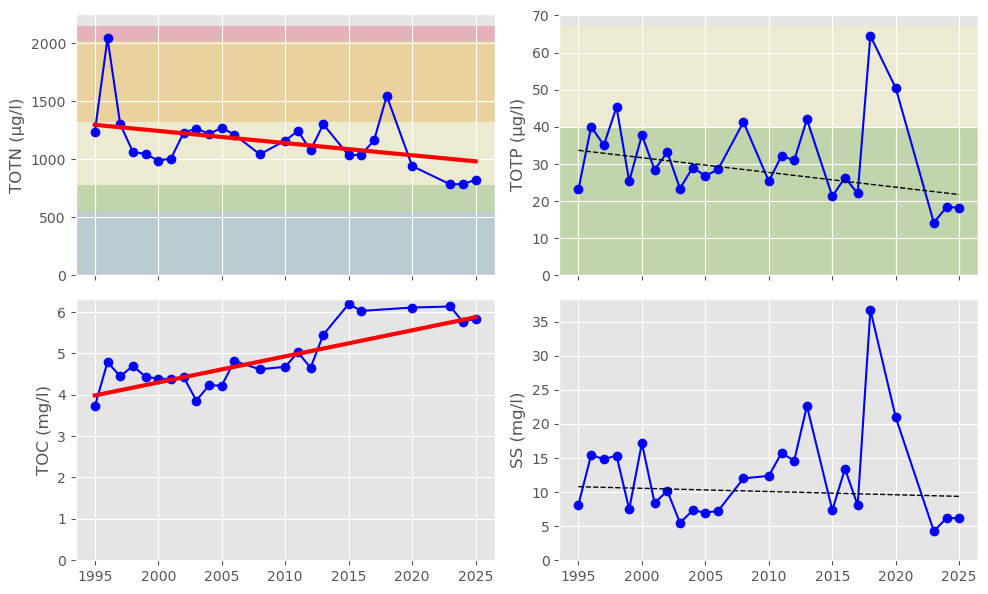

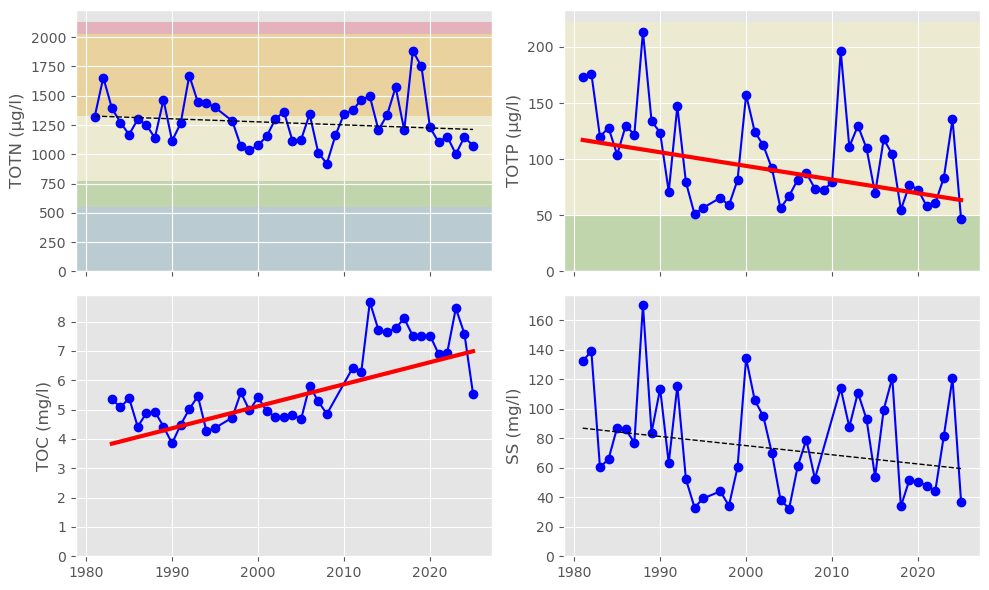

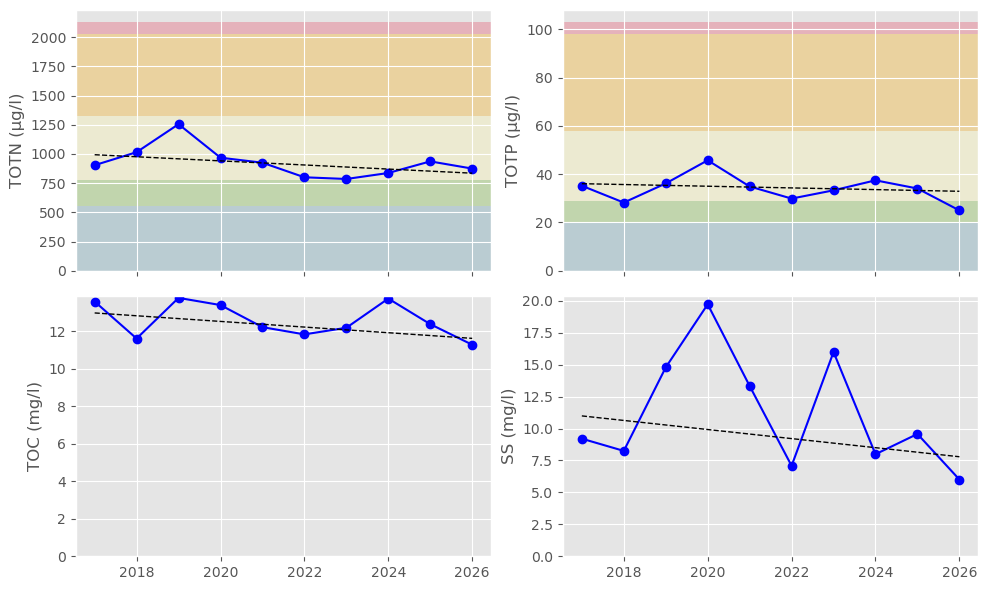

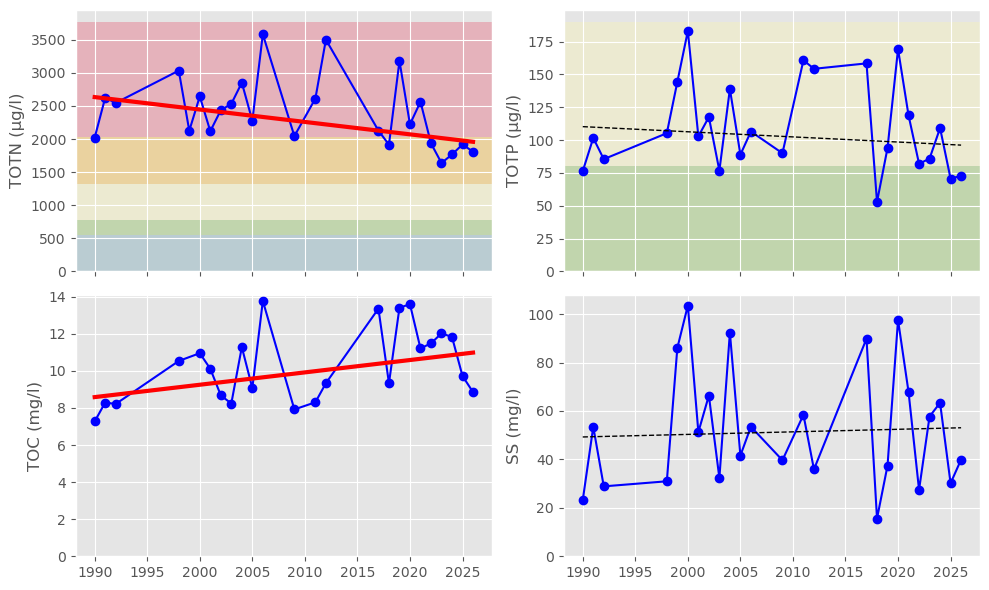

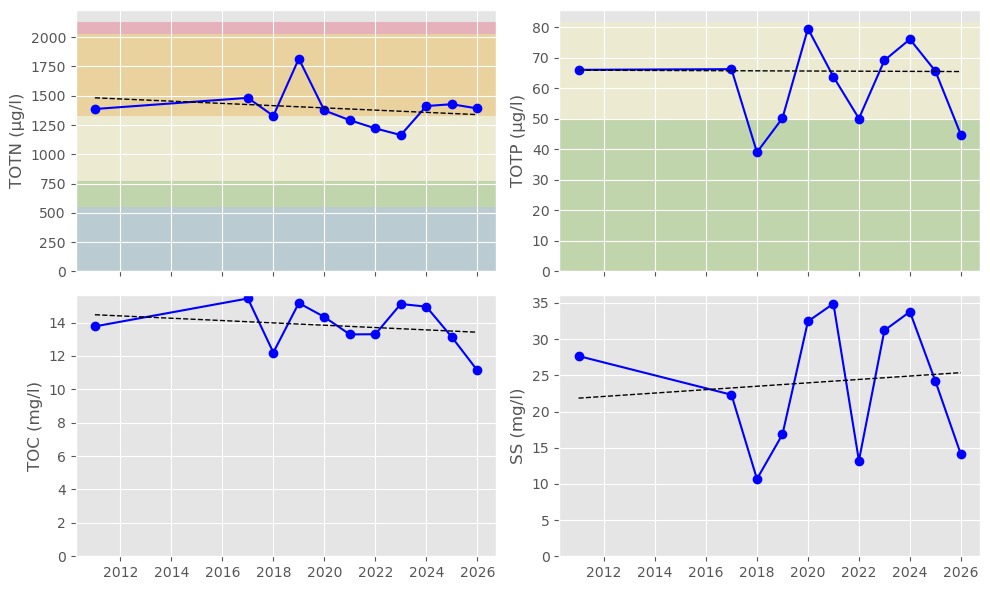

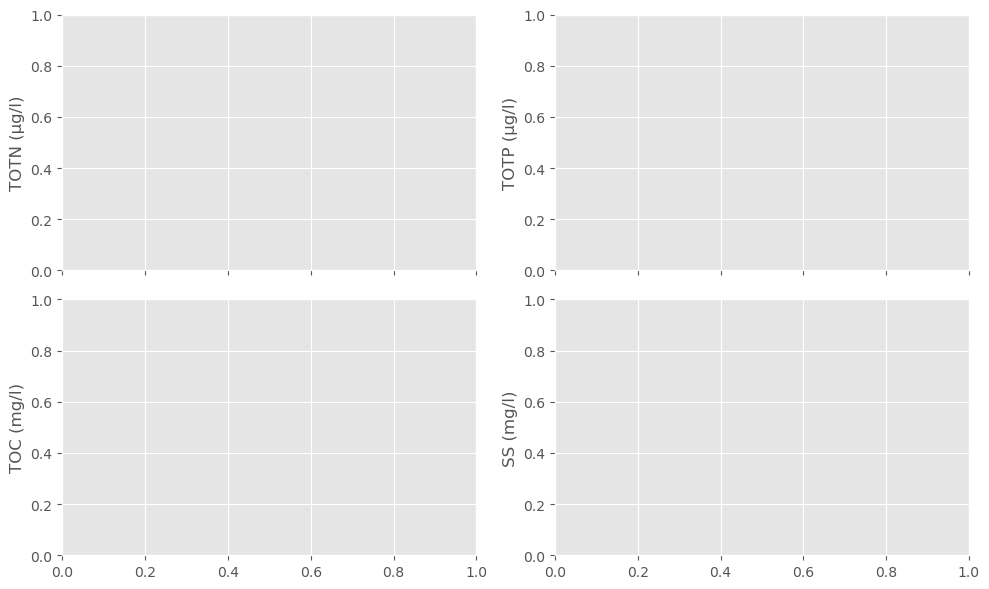

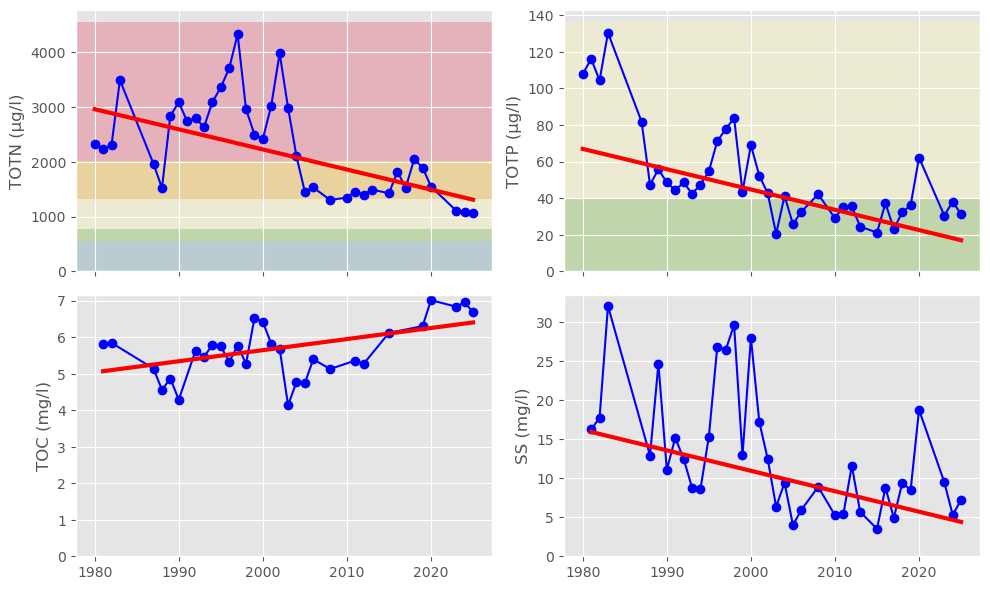

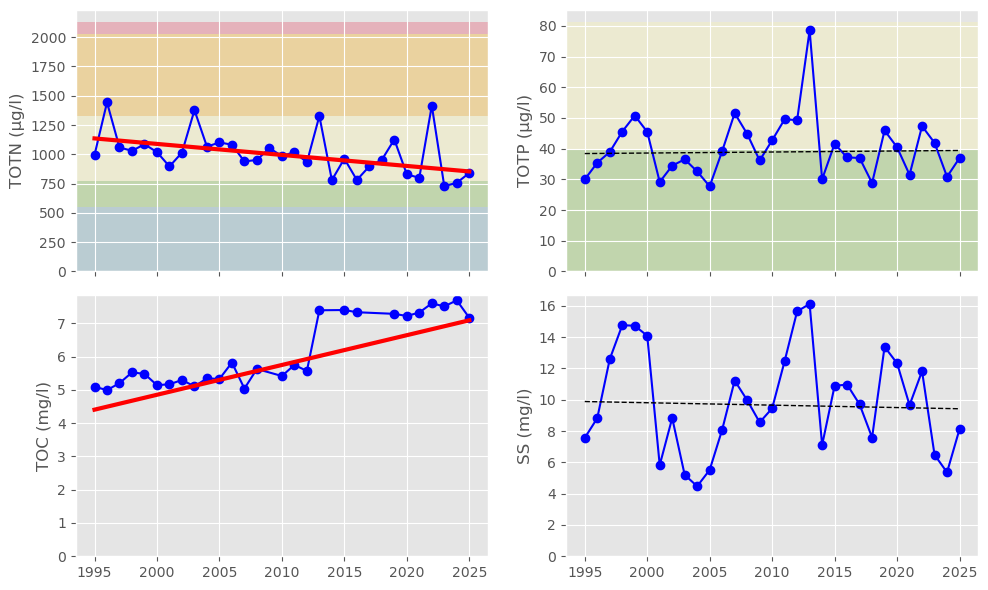

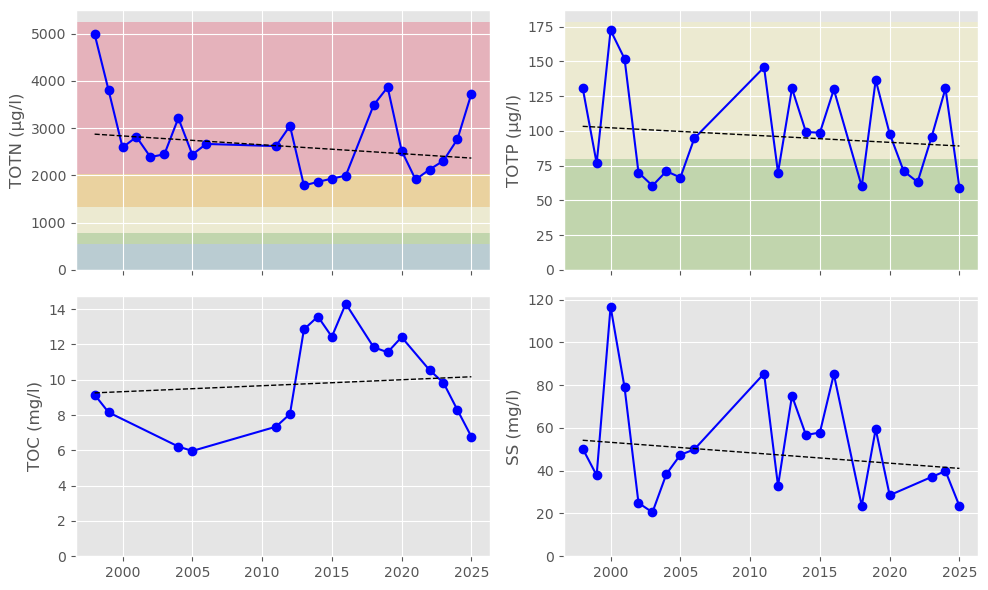

In [16]:
# Trends in concs
xl_path = r"../data/cleaned_concs_waterbodies.xlsx"
ann_df = pd.read_excel(xl_path, sheet_name="annual_avgs")

# WFD thresholds
xl_path = r"../data/vann-nett_data.xlsx"
vn_df = pd.read_excel(xl_path)

# Modified thresholds for leirvassdragene
xl_path = r"../data/leirvassdrag_totp_god-mod_boundaries.xlsx"
clay_df = pd.read_excel(xl_path)

col_order = [
    "TOTN_µg/l",
    "TOTP_µg/l",
    "TOC_mg/l",
    "SS_mg/l",
]

vn_par_dict = {
    "TOTN_µg/l": "Total nitrogen",
    "TOTP_µg/l": "Total phosphorous",
}

wfd_col_dict = {
    "High": "#5893A9",
    "Good": "#6FB22C",
    "Moderate": "#FFF6A6",
    "Poor": "#F6A800",
    "Bad": "#E63D5C",
}

for wb_id, wb_wc_df in ann_df.groupby("waterbody_id"):
    fig, axes = plt.subplots(
        nrows=2,
        ncols=2,
        figsize=(10, 6),
        sharex=True,
        sharey=False,
    )
    axes = axes.flatten()

    wb_wc_df = wb_wc_df.sort_values("year")
    for idx, par in enumerate(col_order):
        par_name, unit = par.split("_")
        wb_par_df = wb_wc_df[["year", par]].dropna(subset=par)
        # I typically only test for trends with >= 10 data points, but Gansåa has fairly good
        # data for 9 years, so relax threshold to >= 9 data points here
        if len(wb_par_df) >= 9:
            # Test for trends
            mk_df = nivapy.stats.mk_test(wb_par_df, par, alpha=0.05)
            res_df, sen_df = nivapy.stats.sens_slope(
                wb_par_df, par, index_col="year", alpha=0.05
            )

            # Extract results
            trend = mk_df.loc["trend", "value"]
            pval = mk_df.loc["p", "value"]
            sslp = res_df.loc["sslp"]["value"]
            icpt = res_df.loc["icpt"]["value"]
            lb = res_df.loc["lb"]["value"]
            ub = res_df.loc["ub"]["value"]

            # Plot
            # Annual concs
            axes[idx].plot(wb_par_df["year"], wb_par_df[par], "bo-")

            # Trend lines
            if trend != "no trend":
                axes[idx].plot(
                    sen_df.index.values,
                    sen_df.index.values * sslp + icpt,
                    "r-",
                    lw=3,
                )
            else:
                if pval <= 0.1:
                    axes[idx].plot(
                        sen_df.index.values,
                        sen_df.index.values * sslp + icpt,
                        "r--",
                        lw=3,
                    )
                else:
                    axes[idx].plot(
                        sen_df.index.values,
                        sen_df.index.values * sslp + icpt,
                        "k--",
                        lw=1,
                    )

            # WFD thresholds
            if par in ("TOTN_µg/l", "TOTP_µg/l"):
                vn_par = vn_par_dict[par]
                wfd_thresh = vn_df.query(
                    "(waterbody_id == @wb_id) and (parameter == @vn_par)"
                ).iloc[0]["status_limits"]
                if isinstance(wfd_thresh, str):
                    wfd_thresh = [float(v) for v in wfd_thresh.split(";")]
                    assert len(wfd_thresh) == 4

                    bounds = [0, *wfd_thresh, 1e9]

                    # First four bands
                    classes = ["High", "Good", "Moderate", "Poor"]
                    for lower, upper, cls in zip(bounds[:-1], bounds[1:], classes):
                        axes[idx].axhspan(
                            lower,
                            upper,
                            facecolor=wfd_col_dict[cls],
                            alpha=0.3,
                            zorder=0,
                        )

                    # Last band, without affecting ymax
                    ymax = axes[idx].get_ylim()[1]
                    axes[idx].axhspan(
                        wfd_thresh[3],
                        ymax,
                        facecolor=wfd_col_dict["Bad"],
                        alpha=0.3,
                        zorder=0,
                    )
                else:
                    if par == "TOTP_µg/l":
                        # Try to get threshold sofr leirvassdragene
                        wfd_thresh = clay_df.query("wb_id == @wb_id").iloc[0][
                            "totp_mod-god_ugpl"
                        ]
                        if isinstance(wfd_thresh, (int, float)):
                            ymax = axes[idx].get_ylim()[1]
                            axes[idx].axhspan(
                                0,
                                wfd_thresh,
                                facecolor=wfd_col_dict["Good"],
                                alpha=0.3,
                                zorder=0,
                            )
                            axes[idx].axhspan(
                                wfd_thresh,
                                ymax,
                                facecolor=wfd_col_dict["Moderate"],
                                alpha=0.3,
                                zorder=0,
                            )

        # Labels
        axes[idx].set_ylabel(f"{par_name} ({unit})")
        axes[idx].set_ylim(bottom=0)

    plt.tight_layout()
    png_path = f"../plots/concs/ann_trends_waterbodies_{wb_id}.png"
    plt.savefig(png_path, dpi=200, bbox_inches="tight")

## 8. Annual loads for waterbodies

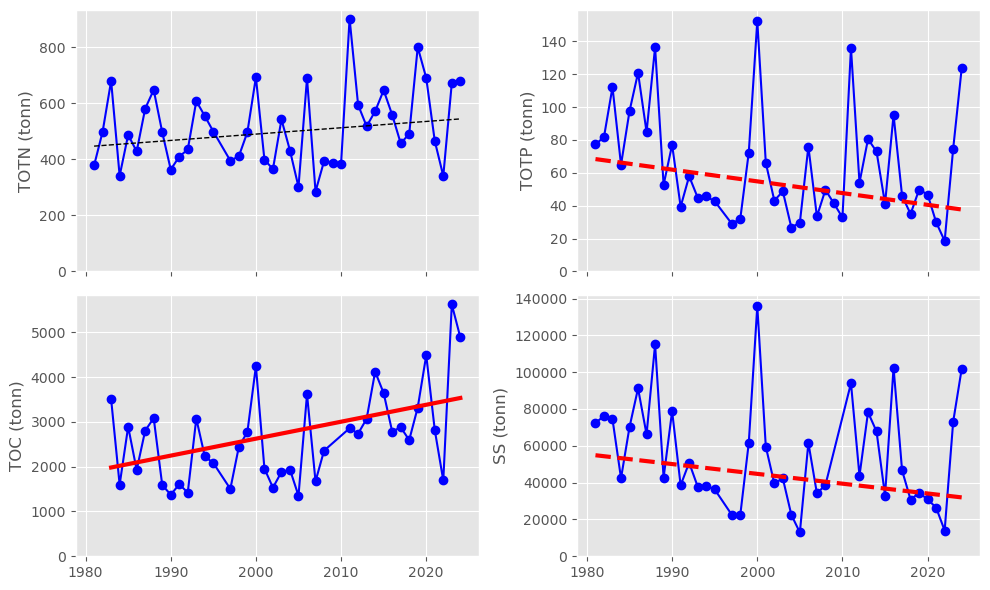

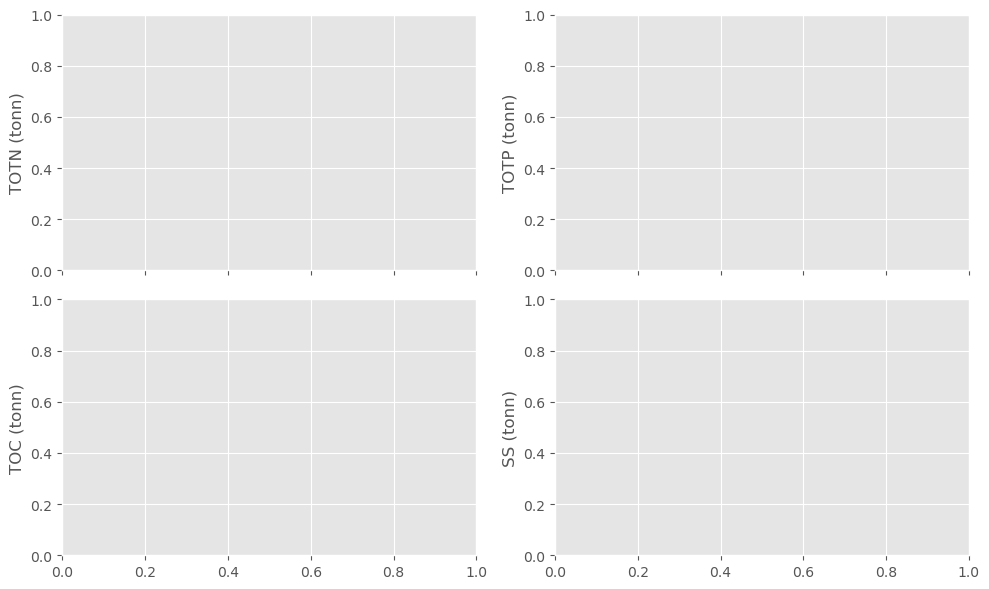

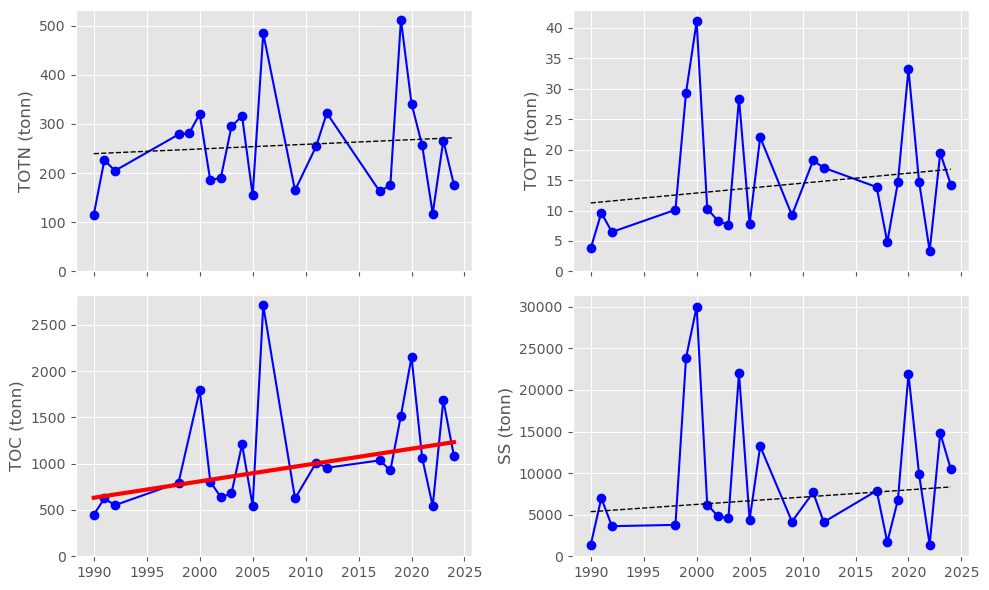

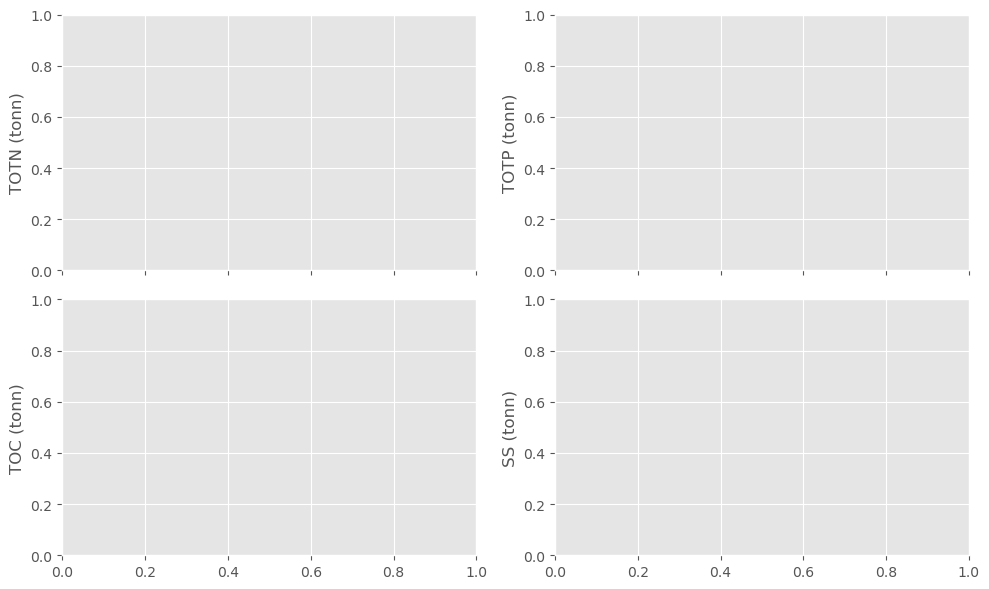

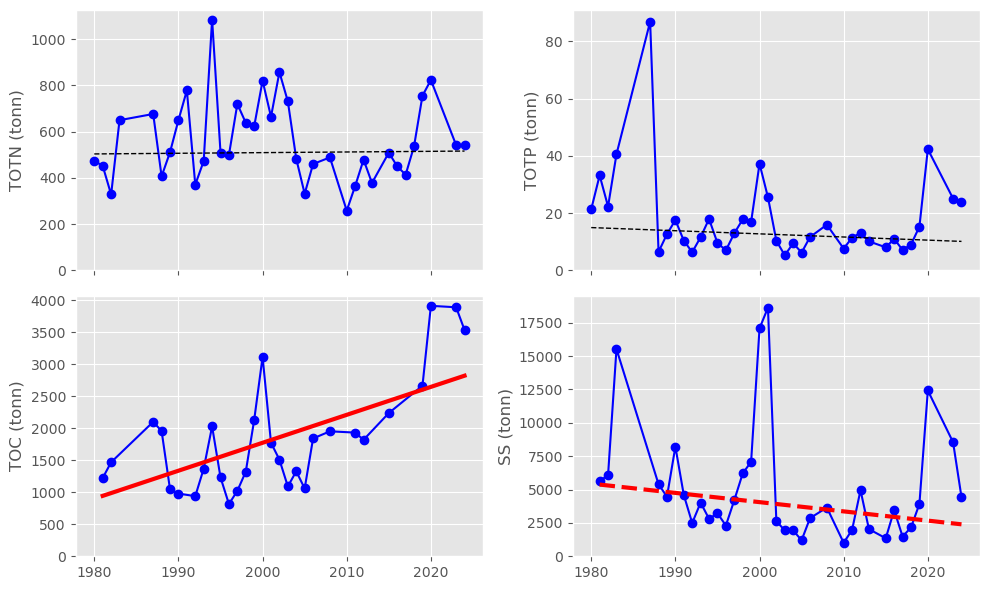

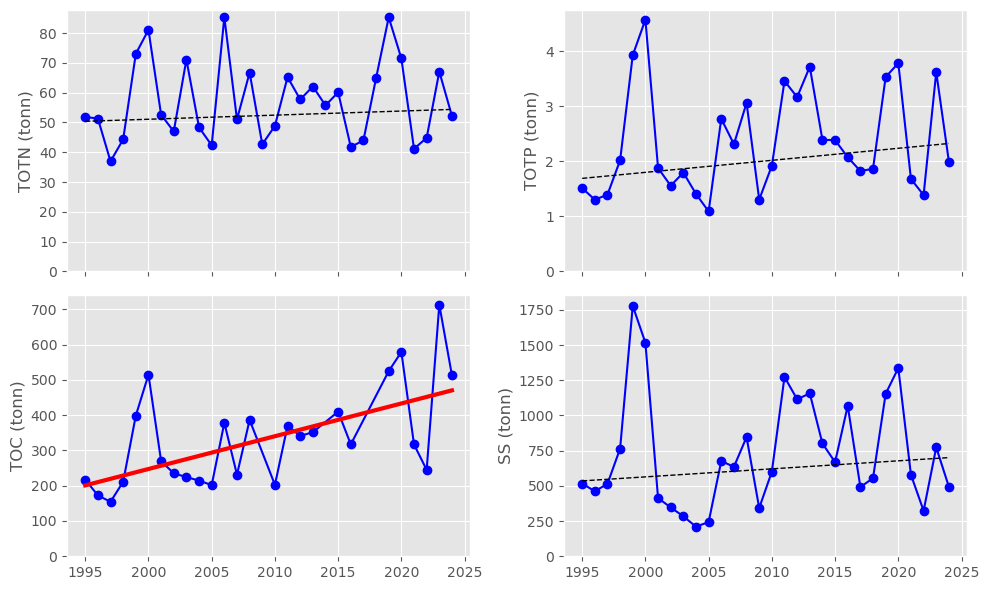

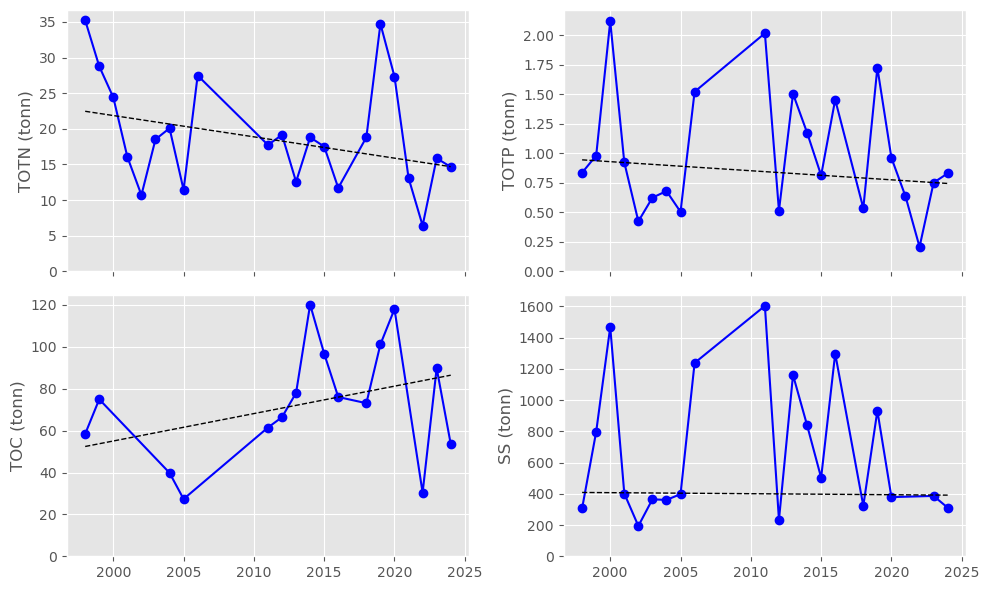

In [17]:
# Trends in loads
xl_path = r"../data/annual_loads_waterbodies.xlsx"
ann_df = pd.read_excel(xl_path, sheet_name="annual_loads")

col_order = [
    "TOTN_tonn",
    "TOTP_tonn",
    "TOC_tonn",
    "SS_tonn",
]

for wb_id, wb_wc_df in ann_df.groupby("waterbody_id"):
    fig, axes = plt.subplots(
        nrows=2,
        ncols=2,
        figsize=(10, 6),
        sharex=True,
        sharey=False,
    )
    axes = axes.flatten()

    wb_wc_df = wb_wc_df.sort_values("year")
    for idx, par in enumerate(col_order):
        par_name, unit = par.split("_")
        wb_par_df = wb_wc_df[["year", par]].dropna(subset=par)
        if len(wb_par_df) > 9:
            # Test for trends
            mk_df = nivapy.stats.mk_test(wb_par_df, par, alpha=0.05)
            res_df, sen_df = nivapy.stats.sens_slope(
                wb_par_df, par, index_col="year", alpha=0.05
            )

            # Extract results
            trend = mk_df.loc["trend", "value"]
            pval = mk_df.loc["p", "value"]
            sslp = res_df.loc["sslp"]["value"]
            icpt = res_df.loc["icpt"]["value"]
            lb = res_df.loc["lb"]["value"]
            ub = res_df.loc["ub"]["value"]

            # Plot
            axes[idx].plot(wb_par_df["year"], wb_par_df[par], "bo-")
            if trend != "no trend":
                axes[idx].plot(
                    sen_df.index.values,
                    sen_df.index.values * sslp + icpt,
                    "r-",
                    lw=3,
                )
            else:
                if pval <= 0.1:
                    axes[idx].plot(
                        sen_df.index.values,
                        sen_df.index.values * sslp + icpt,
                        "r--",
                        lw=3,
                    )
                else:
                    axes[idx].plot(
                        sen_df.index.values,
                        sen_df.index.values * sslp + icpt,
                        "k--",
                        lw=1,
                    )
        axes[idx].set_ylabel(f"{par_name} ({unit})")
        axes[idx].set_ylim(bottom=0)

    plt.tight_layout()
    png_path = f"../plots/loads/ann_trends_waterbodies_{wb_id}.png"
    plt.savefig(png_path, dpi=200, bbox_inches="tight")